In [24]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler

In [ ]:
data=pd.read_csv("ai usage.csv")

In [3]:
data.sample(10)

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
541,SESSION00542,High School,Computer Science,2024-08-03,7.83,2,Research,4,Idea Drafted,True,4.2
7191,SESSION07192,Undergraduate,History,2025-03-25,30.03,8,Research,5,Assignment Completed,True,4.8
6510,SESSION06511,Undergraduate,Business,2025-05-12,29.49,6,Writing,3,Idea Drafted,True,1.2
7393,SESSION07394,Undergraduate,Computer Science,2025-04-18,1.98,1,Homework Help,1,Assignment Completed,False,1.0
5951,SESSION05952,Undergraduate,Math,2024-07-19,18.26,4,Coding,4,Gave Up,True,3.5
4237,SESSION04238,Undergraduate,Business,2024-10-22,7.23,1,Research,4,Idea Drafted,True,4.5
5662,SESSION05663,Undergraduate,Math,2025-05-02,13.50,3,Coding,4,Idea Drafted,True,4.0
4738,SESSION04739,Undergraduate,Biology,2024-11-14,15.31,3,Writing,4,Idea Drafted,True,3.5
9182,SESSION09183,Undergraduate,Psychology,2025-02-09,5.70,2,Writing,2,Idea Drafted,True,1.1
5800,SESSION05801,Graduate,Biology,2024-06-24,0.84,1,Writing,4,Assignment Completed,True,3.0


In [4]:
data.dtypes

SessionID              object
StudentLevel           object
Discipline             object
SessionDate            object
SessionLengthMin      float64
TotalPrompts            int64
TaskType               object
AI_AssistanceLevel      int64
FinalOutcome           object
UsedAgain                bool
SatisfactionRating    float64
dtype: object

In [5]:
data.drop({"SessionID","FinalOutcome","SessionDate","UsedAgain"},axis=1,inplace=True)
data

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,SatisfactionRating
0,Undergraduate,Computer Science,31.20,11,Studying,2,1.0
1,Undergraduate,Psychology,13.09,6,Studying,3,2.0
2,Undergraduate,Business,19.22,5,Coding,3,3.3
3,Undergraduate,Computer Science,3.70,1,Coding,3,3.5
4,Undergraduate,Psychology,28.12,9,Writing,3,2.9
...,...,...,...,...,...,...,...
9995,Undergraduate,Psychology,28.41,5,Studying,3,4.2
9996,High School,Business,13.98,6,Writing,5,5.0
9997,Undergraduate,Biology,10.78,2,Studying,3,3.5
9998,Undergraduate,Business,30.88,7,Writing,3,4.3


In [6]:
data.rename(columns={"AI_AssistanceLevel":"ai level","SatisfactionRating":"rating"},inplace=True)
data

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,ai level,rating
0,Undergraduate,Computer Science,31.20,11,Studying,2,1.0
1,Undergraduate,Psychology,13.09,6,Studying,3,2.0
2,Undergraduate,Business,19.22,5,Coding,3,3.3
3,Undergraduate,Computer Science,3.70,1,Coding,3,3.5
4,Undergraduate,Psychology,28.12,9,Writing,3,2.9
...,...,...,...,...,...,...,...
9995,Undergraduate,Psychology,28.41,5,Studying,3,4.2
9996,High School,Business,13.98,6,Writing,5,5.0
9997,Undergraduate,Biology,10.78,2,Studying,3,3.5
9998,Undergraduate,Business,30.88,7,Writing,3,4.3


In [7]:
data.isnull().sum()

StudentLevel        0
Discipline          0
SessionLengthMin    0
TotalPrompts        0
TaskType            0
ai level            0
rating              0
dtype: int64

In [8]:
data.drop_duplicates(inplace=True)
data.reset_index

<bound method DataFrame.reset_index of        StudentLevel        Discipline  SessionLengthMin  TotalPrompts  \
0     Undergraduate  Computer Science             31.20            11   
1     Undergraduate        Psychology             13.09             6   
2     Undergraduate          Business             19.22             5   
3     Undergraduate  Computer Science              3.70             1   
4     Undergraduate        Psychology             28.12             9   
...             ...               ...               ...           ...   
9995  Undergraduate        Psychology             28.41             5   
9996    High School          Business             13.98             6   
9997  Undergraduate           Biology             10.78             2   
9998  Undergraduate          Business             30.88             7   
9999  Undergraduate              Math             10.85             3   

      TaskType  ai level  rating  
0     Studying         2     1.0  
1     Studying

In [9]:
data.describe()

,SessionLengthMin,TotalPrompts,ai level,rating
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.846467,5.607500,3.479500,3.417780
std,13.897302,4.648764,0.991805,1.143331
min,0.030000,1.000000,1.000000,1.000000
25%,9.630000,2.000000,3.000000,2.600000
50%,16.650000,4.000000,4.000000,3.500000
75%,26.670000,8.000000,4.000000,4.400000
max,110.810000,39.000000,5.000000,5.000000


In [11]:
student_level=set(data.StudentLevel)	
for i,j in enumerate(student_level,start=1):
    print(i,j)


1 High School
2 Undergraduate
3 Graduate


In [12]:
data.StudentLevel.unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

In [15]:
data["StudentLevelnum"]=data.StudentLevel.map({a:i for i,a in enumerate(data.StudentLevel.unique(),start=1)})

In [17]:
data["disciplinenum"]=data.Discipline.map({a:i for i,a in enumerate(data.Discipline.unique(),start=1)})

In [19]:
data

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,ai level,rating,StudentLevelnum,disciplinenum
0,Undergraduate,Computer Science,31.20,11,Studying,2,1.0,1,1
1,Undergraduate,Psychology,13.09,6,Studying,3,2.0,1,2
2,Undergraduate,Business,19.22,5,Coding,3,3.3,1,3
3,Undergraduate,Computer Science,3.70,1,Coding,3,3.5,1,1
4,Undergraduate,Psychology,28.12,9,Writing,3,2.9,1,2
...,...,...,...,...,...,...,...,...,...
9995,Undergraduate,Psychology,28.41,5,Studying,3,4.2,1,2
9996,High School,Business,13.98,6,Writing,5,5.0,3,3
9997,Undergraduate,Biology,10.78,2,Studying,3,3.5,1,4
9998,Undergraduate,Business,30.88,7,Writing,3,4.3,1,3


In [22]:
data.dtypes

StudentLevel         object
Discipline           object
SessionLengthMin    float64
TotalPrompts          int64
TaskType             object
ai level              int64
rating              float64
StudentLevelnum       int64
disciplinenum         int64
dtype: object

In [83]:
numeric_cols=["SessionLengthMin","TotalPrompts","ai level","rating"]
data_clean=data

In [84]:
scaler=MaxAbsScaler()
data_clean[numeric_cols]=scaler.fit_transform(data_clean[numeric_cols])

In [85]:
data_clean

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,ai level,rating,StudentLevelnum,disciplinenum
0,Undergraduate,Computer Science,0.281563,0.282051,Studying,0.4,0.20,0.333333,0.142857
1,Undergraduate,Psychology,0.118130,0.153846,Studying,0.6,0.40,0.333333,0.285714
2,Undergraduate,Business,0.173450,0.128205,Coding,0.6,0.66,0.333333,0.428571
3,Undergraduate,Computer Science,0.033390,0.025641,Coding,0.6,0.70,0.333333,0.142857
4,Undergraduate,Psychology,0.253768,0.230769,Writing,0.6,0.58,0.333333,0.285714
...,...,...,...,...,...,...,...,...,...
9995,Undergraduate,Psychology,0.256385,0.128205,Studying,0.6,0.84,0.333333,0.285714
9996,High School,Business,0.126162,0.153846,Writing,1.0,1.00,1.000000,0.428571
9997,Undergraduate,Biology,0.097284,0.051282,Studying,0.6,0.70,0.333333,0.571429
9998,Undergraduate,Business,0.278675,0.179487,Writing,0.6,0.86,0.333333,0.428571


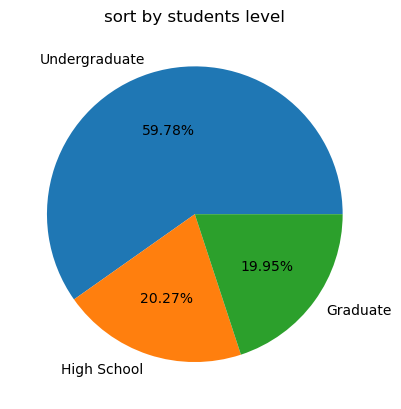

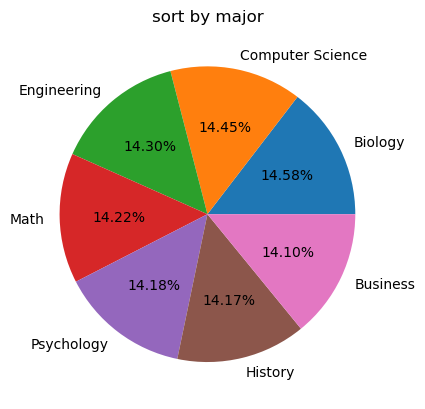

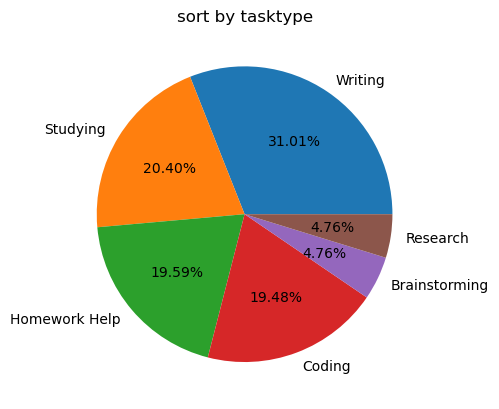

<Figure size 640x480 with 0 Axes>

In [148]:
major_counts,StudentLevel_count,TaskType_value=data["Discipline"].value_counts(),data.StudentLevel.value_counts(),data.TaskType.value_counts()
# major_counts,StudentLevel_count,TaskType_value
plt.pie(StudentLevel_count,labels=StudentLevel_count.index,autopct="%0.2f%%")
plt.title("sort by students level")
plt.show()
plt.pie(major_counts,labels=major_counts.index,autopct="%0.2f%%")
plt.title("sort by major")
plt.show()
plt.pie(TaskType_value,labels=TaskType_value.index,autopct="%0.2f%%")
plt.title("sort by tasktype")
plt.figure()
plt.show()

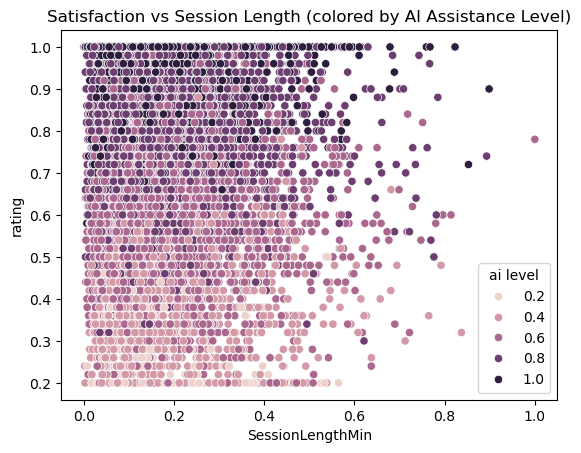

In [87]:
sb.scatterplot(x="SessionLengthMin", y="rating",hue="ai level", data=data_clean)
xlabel='SessionLengthMin'
ylabel='rating'
plt.title("Satisfaction vs Session Length (colored by AI Assistance Level)")
plt.show()

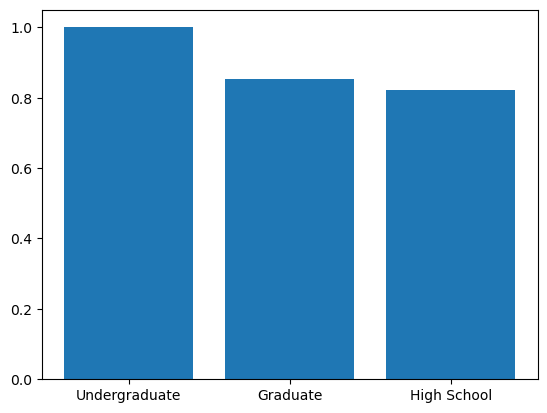

In [147]:
plt.bar("StudentLevel","SessionLengthMin",data=data_clean)
plt.show()

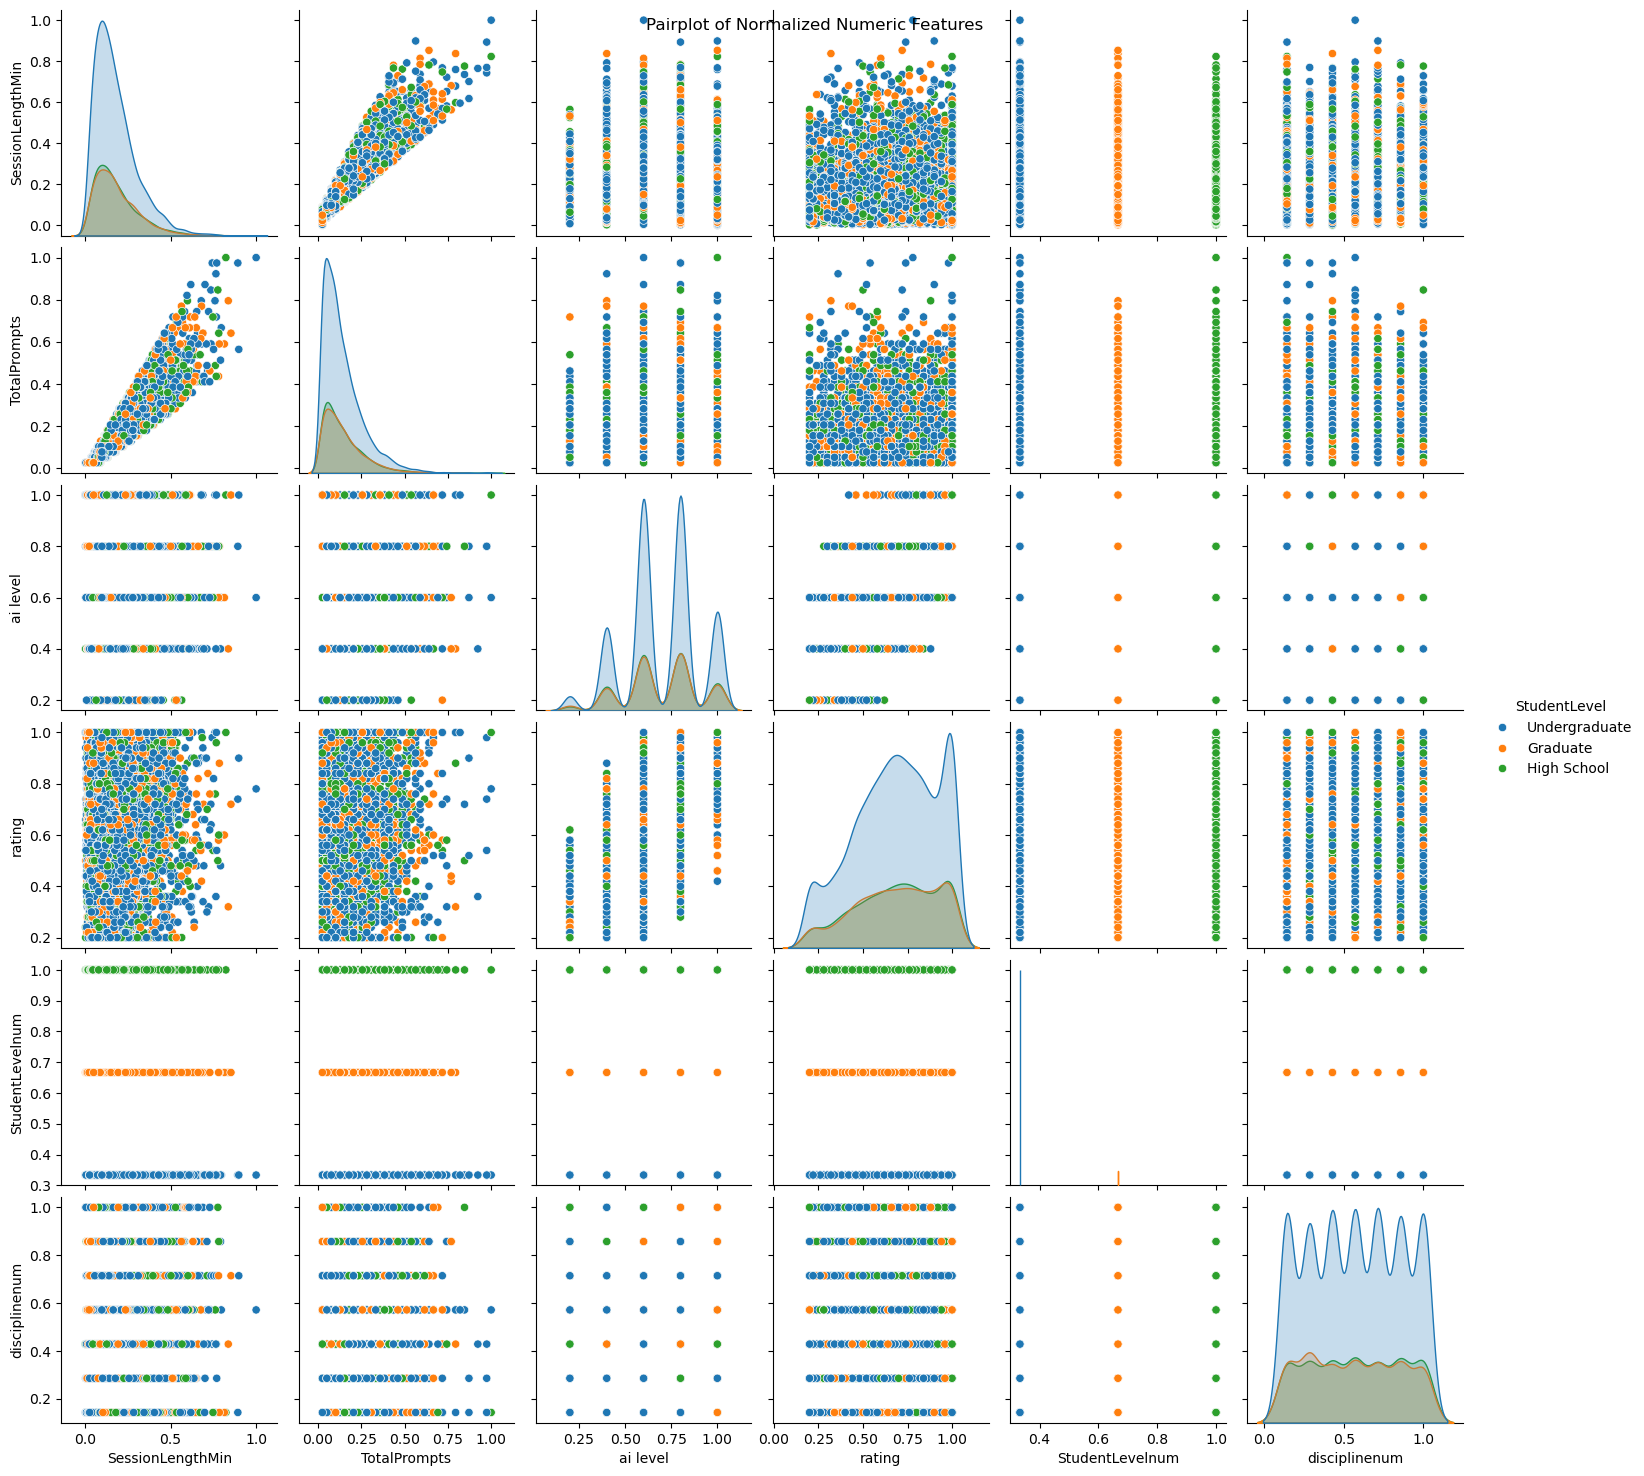

In [136]:
sb.pairplot(data_clean,hue="StudentLevel")
plt.suptitle("Pairplot of Normalized Numeric Features")
plt.show()

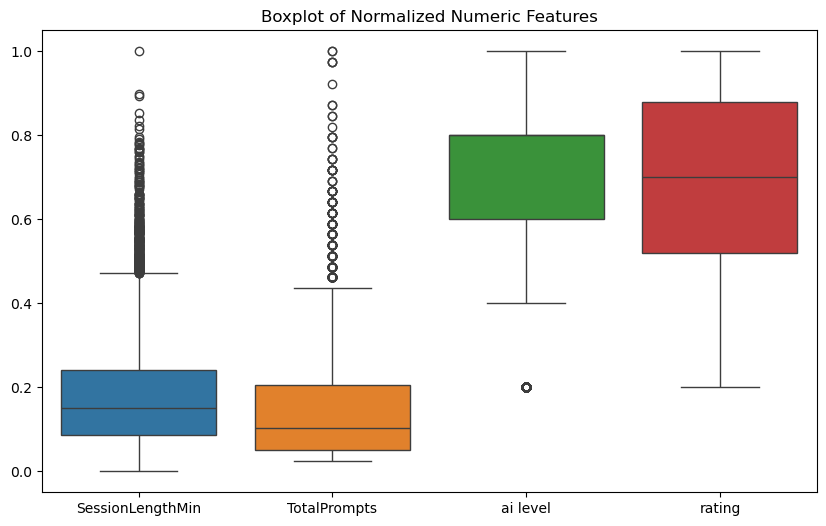

In [90]:
plt.figure(figsize=(10,6))
sb.boxplot(data=data_clean[numeric_cols])
plt.title("Boxplot of Normalized Numeric Features")
plt.show()

In [145]:
corr=data_clean[numeric_cols].corr()
corr

,SessionLengthMin,TotalPrompts,ai level,rating
SessionLengthMin,1.000000,0.902317,-0.006848,-0.011136
TotalPrompts,0.902317,1.000000,-0.006355,-0.009561
ai level,-0.006848,-0.006355,1.000000,0.775513
rating,-0.011136,-0.009561,0.775513,1.000000


<Axes: >

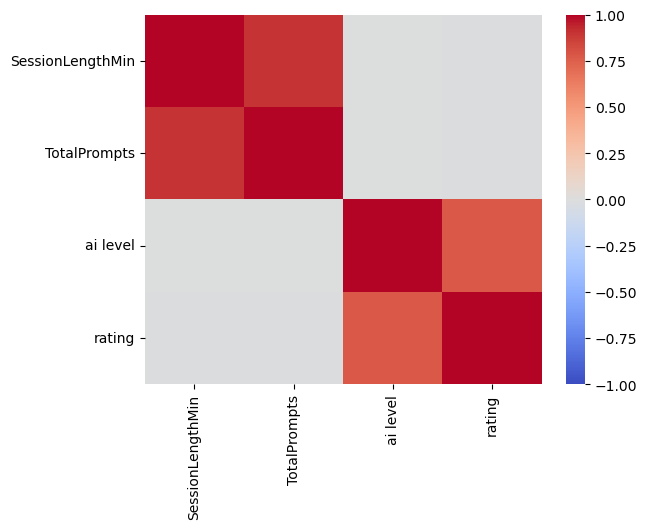

In [146]:
sb.heatmap(corr,vmin=-1,vmax=1,cmap="coolwarm")

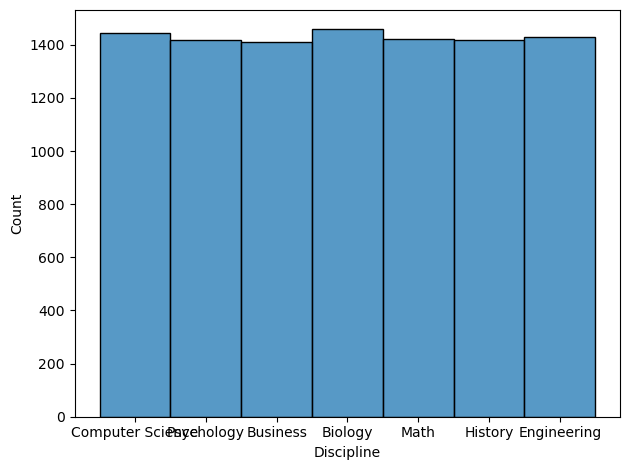

In [152]:
sb.histplot(data_clean.Discipline)
plt.tight_layout()

plt.show()

<Axes: xlabel='count', ylabel='Discipline'>

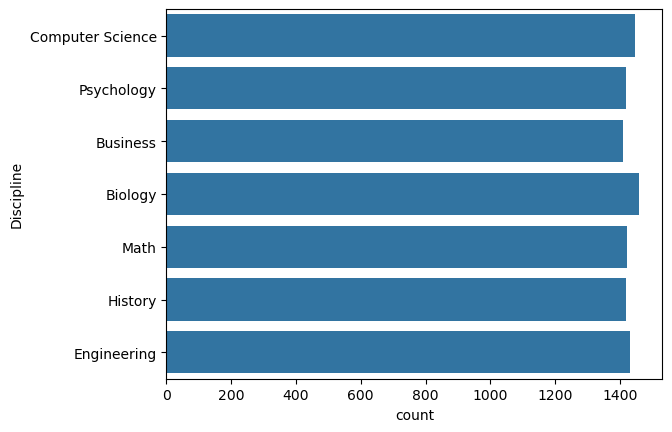

In [154]:
sb.countplot(data_clean.Discipline)

<Axes: xlabel='count', ylabel='StudentLevel'>

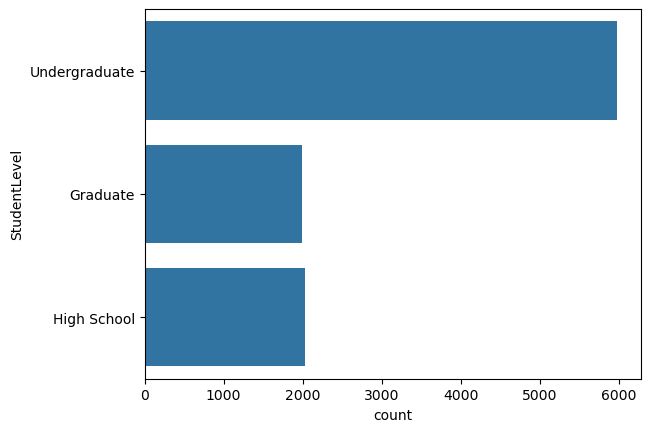

In [155]:
sb.countplot(data_clean.StudentLevel)

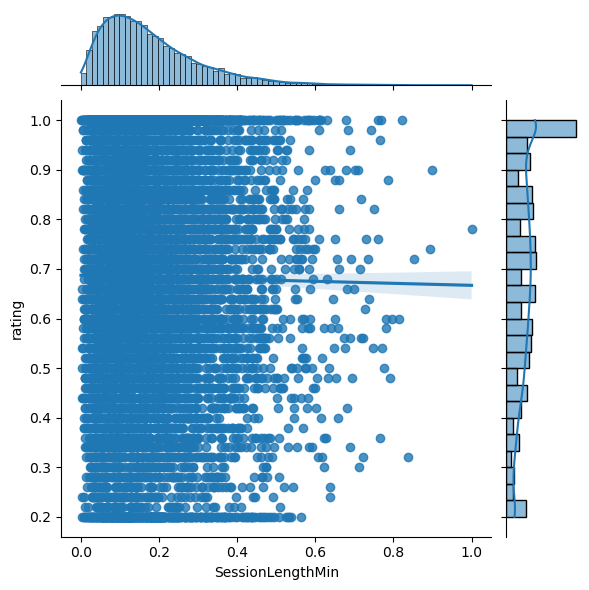

In [159]:
sb.jointplot(data=data_clean, x="SessionLengthMin", y="rating", kind="reg")
plt.show()

Object `path` not found.
